In [1]:
# Cell 1 — Environment setup, imports, dataset loading, model loading

import os
import sys
import math
import numpy as np
import torch
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Device & dtype
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

print("Using device:", device)

# ------------------------------------------------------------
# Ensure src/ is visible (because notebook lives in notebooks/)
# ------------------------------------------------------------
ROOT = os.path.abspath("..")              # project root
SRC_DIR = os.path.join(ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

# ------------------------------------------------------------
# Imports from the package
# ------------------------------------------------------------
from inverse_source_em.training.model_1src import MultitaskNet
from inverse_source_em.surrogate.surrogate import SurrogateEM
from inverse_source_em.surrogate.surrogate_wrapper import SurrogateWrapper
from inverse_source_em.data.dataset_1src import Regression1SrcDataset

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
DATA_PATH = os.path.join(ROOT, "data", "regression", "dataset_1src.npz")
print("Loading dataset:", DATA_PATH)

dataset = Regression1SrcDataset(DATA_PATH, device=device)

X = dataset.X          # (N, 120)
Y = dataset.Y          # (N, 3)
theta_obs = dataset.theta_obs
ymax_E = dataset.ymax_E
ymax_H = dataset.ymax_H
R = dataset.R

N = X.shape[0]
N_train = int(0.9 * N)

X_val = X[N_train:]
Y_val = Y[N_train:]

print("Validation samples:", X_val.shape[0])

# ------------------------------------------------------------
# Load surrogate (canonical)
# ------------------------------------------------------------
PATH_E = os.path.join(ROOT, "models", "surrogate_Esurf.pth")
PATH_H = os.path.join(ROOT, "models", "surrogate_Hsurf.pth")

sur = SurrogateWrapper(
    SurrogateEM(path_E=PATH_E, path_H=PATH_H)
)

print("Surrogate loaded.")

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------
CKPT_DIR = os.path.join(ROOT, "checkpoints", "regression_1src")

ckpt_files = [
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_epoch_") and f.endswith(".pth")
]

if len(ckpt_files) == 0:
    raise RuntimeError("No checkpoints found in regression_1src")

def extract_epoch(fname):
    return int(fname.split("_")[-1].split(".")[0])

epochs = [extract_epoch(f) for f in ckpt_files]
latest_epoch = max(epochs)

best_ckpt = os.path.join(CKPT_DIR, f"best_epoch_{latest_epoch:04d}.pth")
print("Loading checkpoint:", best_ckpt)

model = MultitaskNet(input_dim=120, hidden_dim=256).to(device)
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

print("Model loaded and ready.")


Using device: cpu
Loading dataset: C:\Users\thoma\Projects\inverse-source-em\data\regression\dataset_1src.npz
Validation samples: 2000
Surrogate loaded.
Loading checkpoint: C:\Users\thoma\Projects\inverse-source-em\checkpoints\regression_1src\best_epoch_0199.pth
Model loaded and ready.


In [2]:
# Cell 2 — Helper functions for evaluation

import math
import numpy as np
import torch

# ------------------------------------------------------------
# Add Gaussian noise to the input fields
# ------------------------------------------------------------
def add_noise(X, sigma):
    if sigma == 0.0:
        return X.clone()
    noise = sigma * torch.randn_like(X)
    return X + noise


# ------------------------------------------------------------
# Evaluate model on a dataset (batched)
# Returns arrays of absolute errors
# ------------------------------------------------------------
def evaluate_dataset(X, Y, model, batch_size=256):
    model.eval()

    xy_errors = []
    rho_errors = []
    phi_errors = []
    I_errors = []

    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            Xb = X[i:i+batch_size].to(device)
            Yb = Y[i:i+batch_size].to(device)

            out = model(Xb)
            xy_pred = out["xy"]
            I_pred  = out["I"].view(-1)

            x_true = Yb[:, 0]
            y_true = Yb[:, 1]
            I_true = Yb[:, 2]

            x_pred = xy_pred[:, 0]
            y_pred = xy_pred[:, 1]

            # Cartesian error
            xy_err = torch.sqrt((x_pred - x_true)**2 + (y_pred - y_true)**2)

            # True polar
            rho_true = torch.sqrt(x_true**2 + y_true**2)
            phi_true = torch.atan2(y_true, x_true)

            # Pred polar
            rho_pred = torch.sqrt(x_pred**2 + y_pred**2)
            phi_pred = torch.atan2(y_pred, x_pred)

            # Absolute errors
            rho_err = torch.abs(rho_pred - rho_true)

            dphi = phi_pred - phi_true
            dphi = (dphi + math.pi) % (2 * math.pi) - math.pi
            phi_err = torch.abs(dphi)

            I_err = torch.abs(I_pred - I_true)

            xy_errors.append(xy_err.cpu())
            rho_errors.append(rho_err.cpu())
            phi_errors.append(phi_err.cpu())
            I_errors.append(I_err.cpu())

    xy_errors = torch.cat(xy_errors).numpy()
    rho_errors = torch.cat(rho_errors).numpy()
    phi_errors = torch.cat(phi_errors).numpy()
    I_errors   = torch.cat(I_errors).numpy()

    return xy_errors, rho_errors, phi_errors, I_errors


# ------------------------------------------------------------
# Print summary statistics for an error array
# ------------------------------------------------------------
def summarize(name, arr):
    print(
        f"{name}: mean={np.mean(arr):.6f}, "
        f"p50={np.percentile(arr,50):.6f}, "
        f"p90={np.percentile(arr,90):.6f}, "
        f"p99={np.percentile(arr,99):.6f}"
    )


In [5]:
# Cell 3 — Relative errors, DataFrame evaluation, summary tables

import pandas as pd
import numpy as np
import torch
import math

# ------------------------------------------------------------
# Compute relative errors (avoid division by zero)
# ------------------------------------------------------------
def compute_relative_errors(rho_err, rho_true, I_err, I_true):
    rho_rel = rho_err / np.maximum(rho_true, 1e-12)
    I_rel   = I_err   / np.maximum(I_true, 1e-12)
    return rho_rel, I_rel


# ------------------------------------------------------------
# Evaluate model and return a pandas DataFrame with all metrics
# ------------------------------------------------------------
def evaluate_with_tables(X, Y, model, batch_size=256):
    model.eval()

    xy_all = []
    rho_all = []
    phi_all = []
    I_all = []
    rho_true_all = []
    I_true_all = []

    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            Xb = X[i:i+batch_size].to(device, dtype=torch.float64)
            Yb = Y[i:i+batch_size].to(device, dtype=torch.float64)

            out = model(Xb)
            xy_pred = out["xy"]
            I_pred  = out["I"].view(-1)

            x_true = Yb[:, 0]
            y_true = Yb[:, 1]
            I_true = Yb[:, 2]

            x_pred = xy_pred[:, 0]
            y_pred = xy_pred[:, 1]

            xy_err = torch.sqrt((x_pred - x_true)**2 + (y_pred - y_true)**2)

            rho_true = torch.sqrt(x_true**2 + y_true**2)
            phi_true = torch.atan2(y_true, x_true)

            rho_pred = torch.sqrt(x_pred**2 + y_pred**2)
            phi_pred = torch.atan2(y_pred, x_pred)

            rho_err = torch.abs(rho_pred - rho_true)

            dphi = phi_pred - phi_true
            dphi = (dphi + math.pi) % (2 * math.pi) - math.pi
            phi_err = torch.abs(dphi)

            I_err = torch.abs(I_pred - I_true)

            xy_all.append(xy_err.cpu())
            rho_all.append(rho_err.cpu())
            phi_all.append(phi_err.cpu())
            I_all.append(I_err.cpu())
            rho_true_all.append(rho_true.cpu())
            I_true_all.append(I_true.cpu())

    xy_all = torch.cat(xy_all).numpy()
    rho_all = torch.cat(rho_all).numpy()
    phi_all = torch.cat(phi_all).numpy()
    I_all   = torch.cat(I_all).numpy()
    rho_true_all = torch.cat(rho_true_all).numpy()
    I_true_all   = torch.cat(I_true_all).numpy()

    rho_rel, I_rel = compute_relative_errors(rho_all, rho_true_all, I_all, I_true_all)

    df = pd.DataFrame({
        "xy_abs": xy_all,
        "rho_abs": rho_all,
        "rho_rel": rho_rel,
        "phi_abs": phi_all,
        "I_abs": I_all,
        "I_rel": I_rel
    })

    return df


# ------------------------------------------------------------
# Print summary statistics for the DataFrame
# ------------------------------------------------------------
def summarize_table(df, title):
    print(f"\n=== {title} ===\n")
    stats = df.describe(percentiles=[0.5, 0.9, 0.99]).loc[["mean", "50%", "90%", "99%"]]
    print(stats)


In [6]:
# Cell 4 — Evaluate model under multiple noise levels

noise_levels = [0.0, 0.01, 0.03, 0.05, 0.10]

for sigma in noise_levels:
    if sigma == 0.0:
        X_eval = X_val.clone()
        title = "Zero Noise"
    else:
        X_eval = add_noise(X_val, sigma)
        title = f"Noise σ = {sigma}"

    df = evaluate_with_tables(X_eval, Y_val, model)
    summarize_table(df, title)



=== Zero Noise ===

        xy_abs   rho_abs   rho_rel   phi_abs     I_abs     I_rel
mean  0.000935  0.000595  0.001171  0.001235  0.000223  0.000223
50%   0.000881  0.000500  0.000846  0.000845  0.000195  0.000195
90%   0.001602  0.001227  0.002155  0.002444  0.000452  0.000452
99%   0.002295  0.001963  0.007217  0.007969  0.000721  0.000721

=== Noise σ = 0.01 ===

        xy_abs   rho_abs   rho_rel   phi_abs     I_abs     I_rel
mean  0.002399  0.001657  0.003352  0.002966  0.000307  0.000307
50%   0.002271  0.001364  0.002321  0.001922  0.000248  0.000248
90%   0.004104  0.003454  0.006734  0.006220  0.000652  0.000652
99%   0.006183  0.005582  0.022896  0.019489  0.001106  0.001106

=== Noise σ = 0.03 ===

        xy_abs   rho_abs   rho_rel   phi_abs     I_abs     I_rel
mean  0.006626  0.004640  0.009494  0.008196  0.000670  0.000670
50%   0.006169  0.003951  0.006406  0.005130  0.000479  0.000479
90%   0.011546  0.009789  0.018814  0.017095  0.001451  0.001451
99%   0.016773  0.0

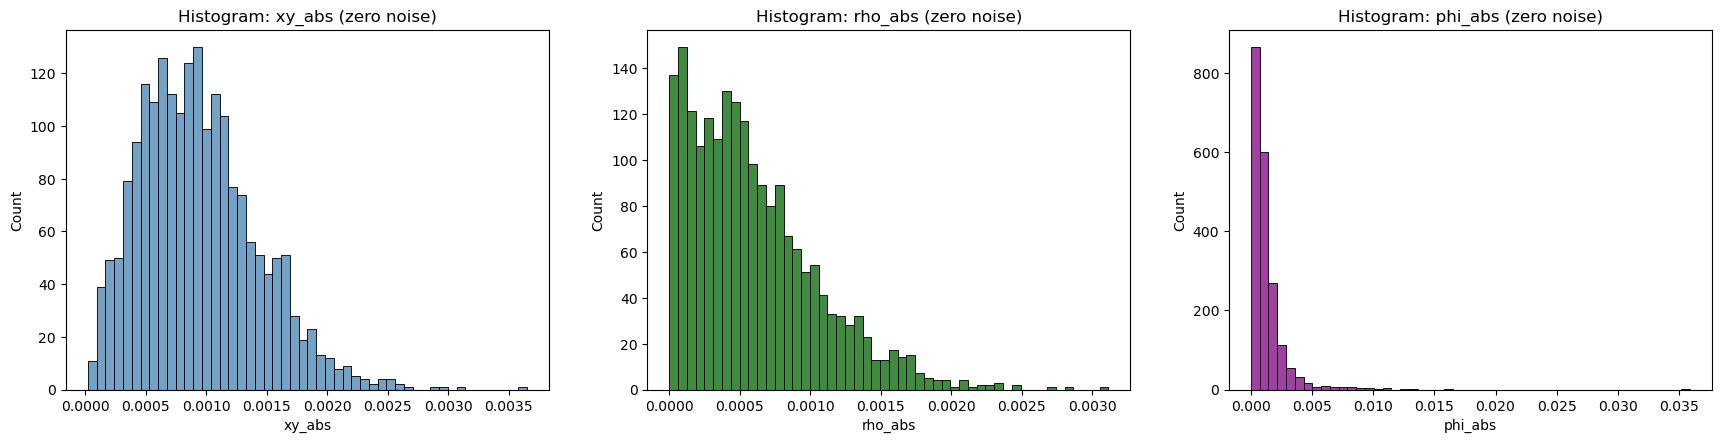

In [7]:
# Cell 5 — Histograms for zero-noise evaluation (print-ready)

import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate zero-noise case
df0 = evaluate_with_tables(X_val.clone(), Y_val.clone(), model)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.tight_layout(pad=4.0)

# Histogram: xy_abs
sns.histplot(df0["xy_abs"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram: xy_abs (zero noise)")
axes[0].set_xlabel("xy_abs")

# Histogram: rho_abs
sns.histplot(df0["rho_abs"], bins=50, ax=axes[1], color="darkgreen")
axes[1].set_title("Histogram: rho_abs (zero noise)")
axes[1].set_xlabel("rho_abs")

# Histogram: phi_abs
sns.histplot(df0["phi_abs"], bins=50, ax=axes[2], color="purple")
axes[2].set_title("Histogram: phi_abs (zero noise)")
axes[2].set_xlabel("phi_abs")

plt.show()


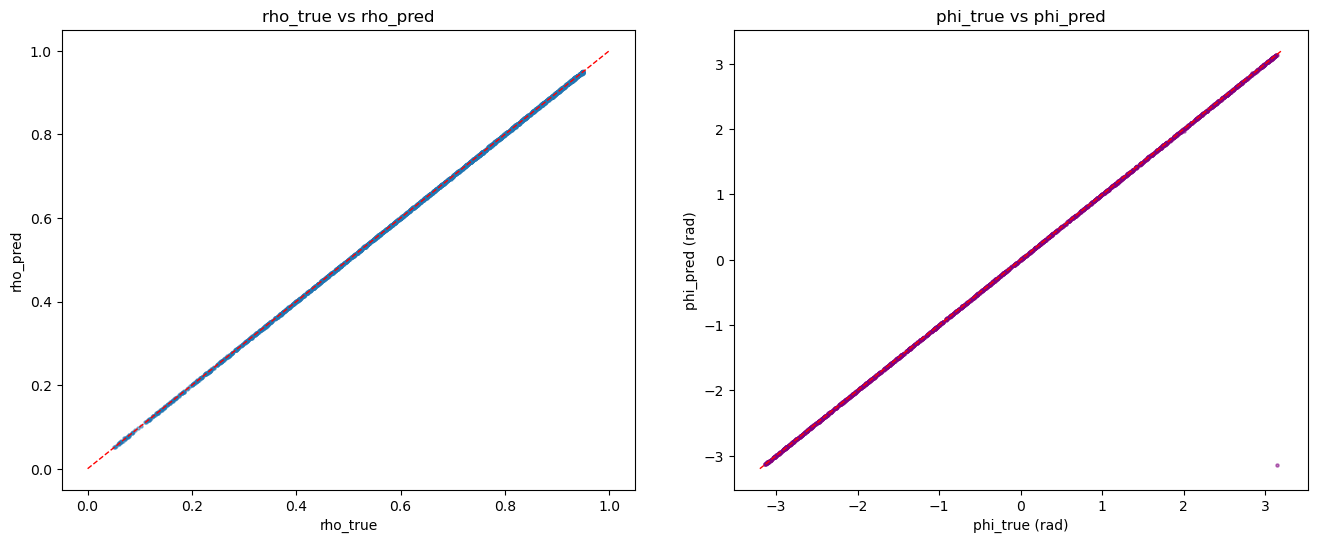

In [8]:
# Cell 6 — Scatter plots for zero-noise evaluation (print-ready)

import matplotlib.pyplot as plt
import seaborn as sns

# Forward pass on validation set
with torch.no_grad():
    out = model(X_val.to(device, dtype=torch.float64))
    xy_pred = out["xy"].cpu()

# True values
x_true = Y_val[:, 0]
y_true = Y_val[:, 1]

# Convert to polar (true)
rho_true = torch.sqrt(x_true**2 + y_true**2)
phi_true = torch.atan2(y_true, x_true)

# Predicted polar
x_pred = xy_pred[:, 0]
y_pred = xy_pred[:, 1]

rho_pred = torch.sqrt(x_pred**2 + y_pred**2)
phi_pred = torch.atan2(y_pred, x_pred)

# Convert to numpy
rho_true_np = rho_true.numpy()
rho_pred_np = rho_pred.numpy()
phi_true_np = phi_true.numpy()
phi_pred_np = phi_pred.numpy()

# Plot: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.tight_layout(pad=4.0)

# ρ scatter
axes[0].scatter(rho_true_np, rho_pred_np, s=5, alpha=0.5)
axes[0].set_title("rho_true vs rho_pred")
axes[0].set_xlabel("rho_true")
axes[0].set_ylabel("rho_pred")
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1)

# φ scatter
axes[1].scatter(phi_true_np, phi_pred_np, s=5, alpha=0.5, color="purple")
axes[1].set_title("phi_true vs phi_pred")
axes[1].set_xlabel("phi_true (rad)")
axes[1].set_ylabel("phi_pred (rad)")
axes[1].plot([-3.2, 3.2], [-3.2, 3.2], 'r--', linewidth=1)

plt.show()
